In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv('german_credit_data_clean.csv')
df

,Age,Sex,Job,Housing,Saving Accounts,Checking Account,Credit Amount,Duration,Purpose,Age Group,Risk Exposure Tiers
0,67,Male,2,Own,Unknown,Little,1169,6,Radio/Tv,Senior,Low Exposure
1,22,Female,2,Own,Little,Moderate,5951,48,Radio/Tv,Young Adult,High Exposure
2,49,Male,1,Own,Little,Unknown,2096,12,Education,Middle-Aged,Medium Exposure
3,45,Male,2,Free,Little,Little,7882,42,Furniture/Equipment,Middle-Aged,High Exposure
4,53,Male,2,Free,Little,Little,4870,24,Car,Senior,High Exposure
...,...,...,...,...,...,...,...,...,...,...,...
995,31,Female,1,Own,Little,Unknown,1736,12,Furniture/Equipment,Middle-Aged,Medium Exposure
996,40,Male,3,Own,Little,Little,3857,30,Car,Middle-Aged,Medium Exposure
997,38,Male,2,Own,Little,Unknown,804,12,Radio/Tv,Middle-Aged,Low Exposure
998,23,Male,2,Free,Little,Little,1845,45,Radio/Tv,Young Adult,Medium Exposure


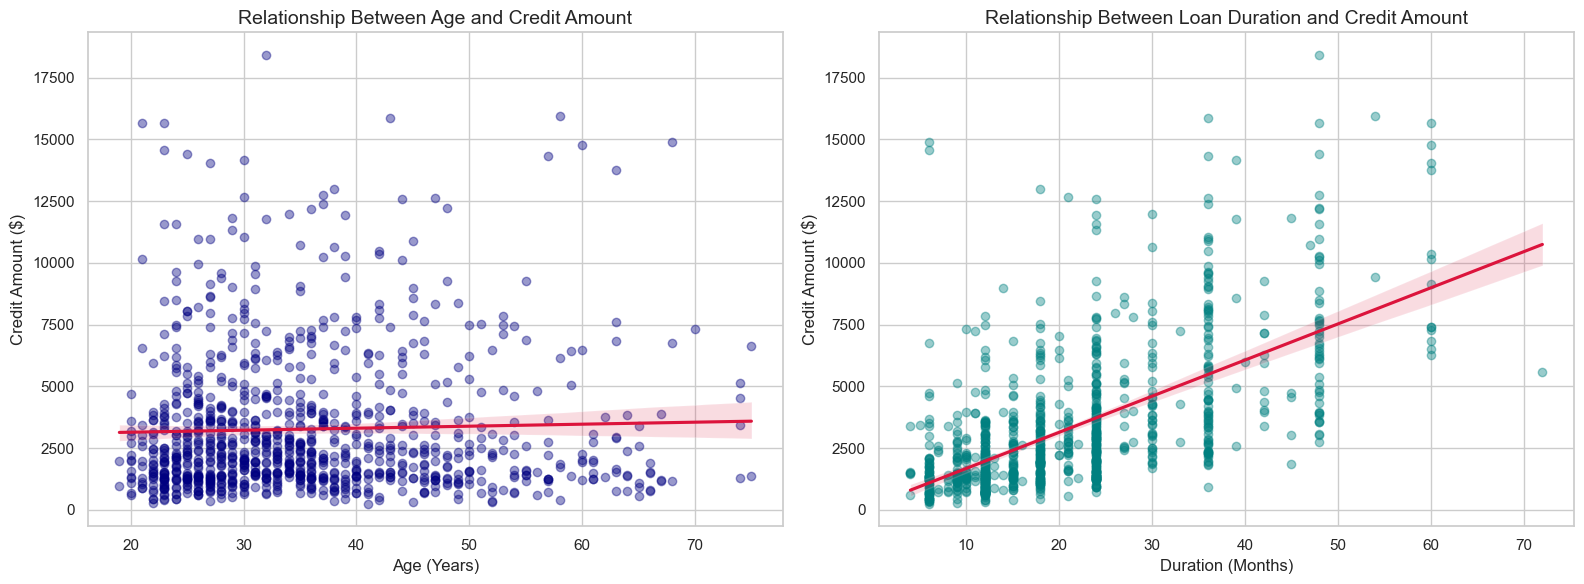

----CORRELATION METRIX----
                    Age  Duration  Credit Amount
Age            1.000000 -0.036136       0.032716
Duration      -0.036136  1.000000       0.624984
Credit Amount  0.032716  0.624984       1.000000


In [3]:
# Step 1: Statistical Correlation & Relationship Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

sns.regplot(data=df, x='Age', y='Credit Amount', ax=ax1,
            scatter_kws={'alpha': 0.4, 'color': 'navy'}, line_kws={'color': 'crimson'})
ax1.set_title('Relationship Between Age and Credit Amount', fontsize=14)
ax1.set_xlabel('Age (Years)', fontsize=12)
ax1.set_ylabel('Credit Amount ($)', fontsize=12)

sns.regplot(data=df, x='Duration', y='Credit Amount', ax=ax2,
            scatter_kws={'alpha': 0.4, 'color': 'teal'}, line_kws={'color': 'crimson'})
ax2.set_title('Relationship Between Loan Duration and Credit Amount', fontsize=14)
ax2.set_xlabel('Duration (Months)', fontsize=12)
ax2.set_ylabel('Credit Amount ($)', fontsize=12)

plt.tight_layout()
plt.show()

print('----CORRELATION METRIX----')
print(df[['Age', 'Duration', 'Credit Amount']].corr())

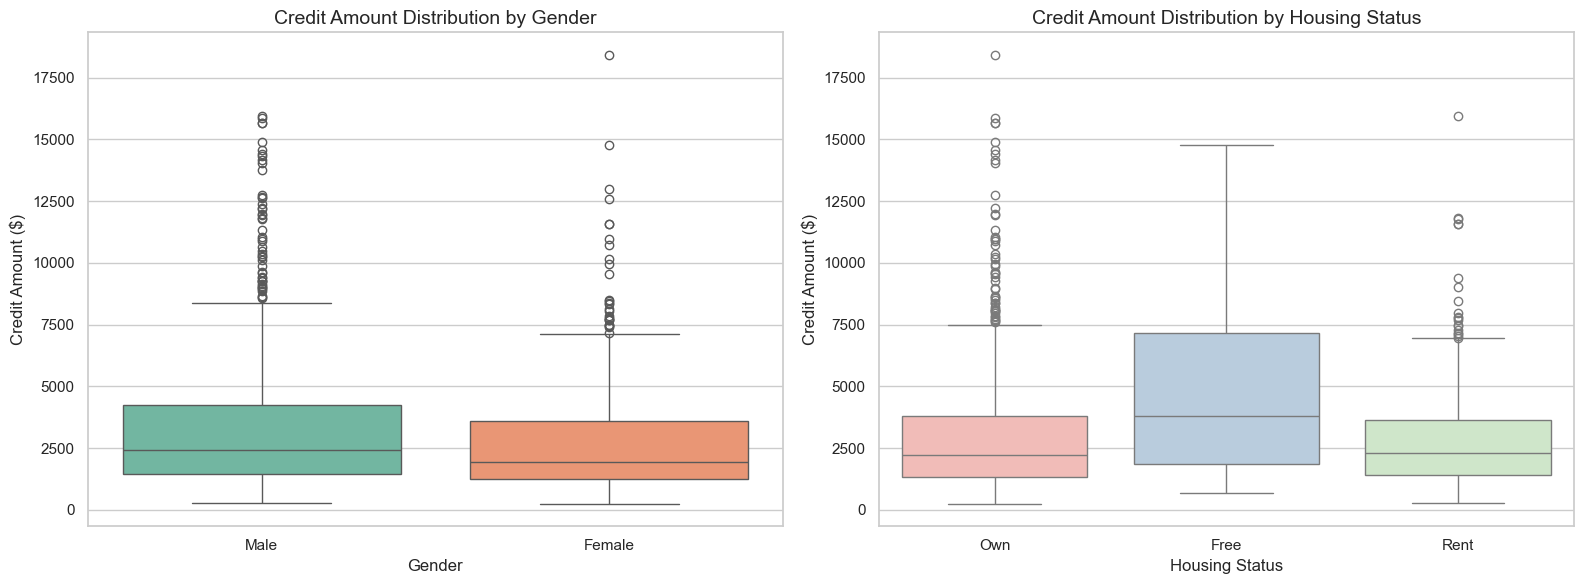

In [4]:
# Step 2: Investigating Categorical Risk (The Distribution of Risk Factors)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

sns.boxplot(data=df, x='Sex', y='Credit Amount', palette='Set2', hue='Sex', legend=False, ax=ax1)
ax1.set_title('Credit Amount Distribution by Gender', fontsize=14)
ax1.set_xlabel('Gender', fontsize=12)
ax1.set_ylabel('Credit Amount ($)', fontsize=12)

sns.boxplot(data=df, x='Housing', y='Credit Amount', palette='Pastel1', hue='Housing', legend=False, ax=ax2)
ax2.set_title('Credit Amount Distribution by Housing Status', fontsize=14)
ax2.set_xlabel('Housing Status', fontsize=12)
ax2.set_ylabel('Credit Amount ($)', fontsize=12)

plt.tight_layout()
plt.show()

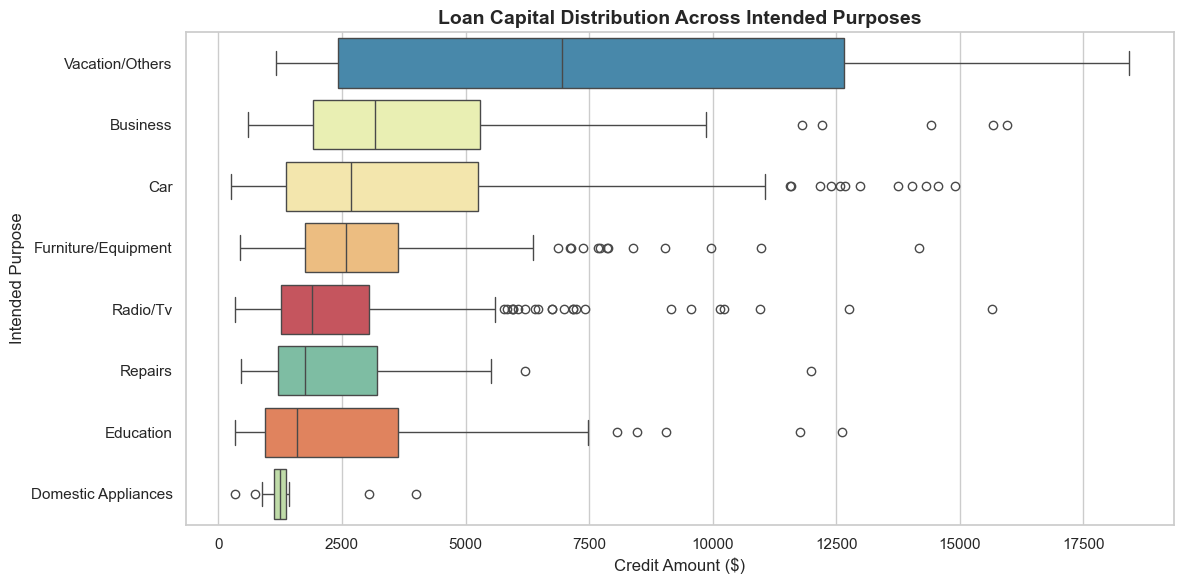

In [5]:
# Step 3: Deep-Dive into the 'Purpose' Column (The Final EDA Milestone)
purpose_order = df.groupby('Purpose')['Credit Amount'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(12,6))
sns.boxplot(data=df, x='Credit Amount', y='Purpose', hue='Purpose', legend=False, order=purpose_order, palette='Spectral', ax=ax)
ax.set_title('Loan Capital Distribution Across Intended Purposes', fontsize=14, fontweight='bold')
ax.set_xlabel('Credit Amount ($)', fontsize=12)
ax.set_ylabel('Intended Purpose', fontsize=12)
plt.tight_layout()
plt.show()

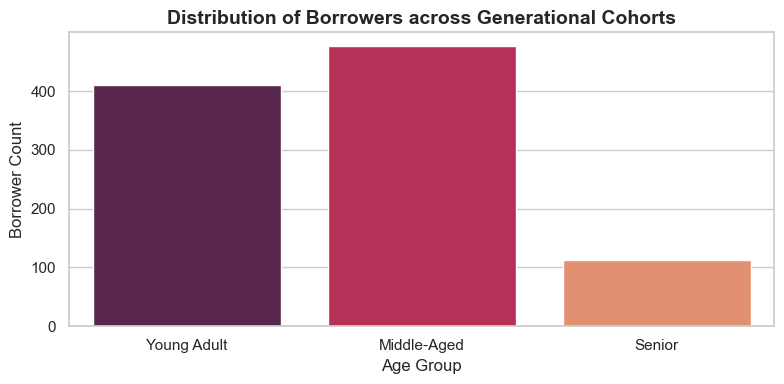

In [35]:
# Creating Custom Age Brackets
age_bins = [18, 30, 50, 100]
age_labels = ['Young Adult', 'Middle-Aged', 'Senior']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

fig, ax = plt.subplots(figsize=(8,4))
sns.countplot(data=df, x='Age Group', hue='Age Group', legend=False, palette='rocket', ax=ax)
ax.set_title('Distribution of Borrowers across Generational Cohorts', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Borrower Count', fontsize=12)

plt.tight_layout()
plt.show()

In [36]:
df['Credit Amount'].describe()

count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: Credit Amount, dtype: float64

In [39]:
credit_bins = [0, 1500, 4000, 20000]
credit_labels = ['Low Exposure', 'Medium Exposure', 'High Exposure']
df['Risk Exposure Tiers'] = pd.cut(df['Credit Amount'], bins=credit_bins, labels=credit_labels)

print('----RISK EXPOSURE BY AGE GROUP---')
pd.crosstab(df['Age Group'], df['Risk Exposure Tiers'])

----RISK EXPOSURE BY AGE GROUP---


Risk Exposure Tiers,Low Exposure,Medium Exposure,High Exposure
Age Group,,,
Young Adult,136,178,97
Middle-Aged,129,226,121
Senior,41,44,28


In [40]:
# Overwrite our clean CSV to include our brand-new engineered features
df.to_csv('german_credit_data_clean.csv', index=False)
print("Features successfully saved to the production dataset!")

Features successfully saved to the production dataset!
